In [467]:
# This program was original made by following along with Codemy.com tutorials on YouTube.
# Playlist here:
# https://youtube.com/playlist?list=PLCC34OHNcOtpcgR9LEYSdi9r7XIbpkpK1&si=qN9cA47jvIpXJ6Ez

# It has since been modified for use with the NASA Turbofan Jet Engine Data Set for a Machine Learning in ME course at UC Berkeley.

In [468]:
import torch # Import the PyTorch library
import torch.nn as nn # Import the neural network module from PyTorch for defining layers and loss functions
import torch.nn.functional as F # Import functional interface for operations like activation functions (ReLU)

In [ ]:
# Create a Model Class that inherits nn.Module, the base class for all neural network modules in PyTorch
class Model(nn.Module):
  # Input layer (24 features of the Engine) -->
  # Hidden Layer1 (number of neurons) --> 128
  # H2 (n) --> 64
  # H3 (n) --> 32
  # H4 (n) --> 16
  # output (1 value for RUL prediction)
  def __init__(self, in_features=24, h1=128, h2=64, h3=32, h4=16, out_features=1, dropout=0.2):
    super().__init__() # instantiate our nn.Module, initializing the parent class
    self.fc1 = nn.Linear(in_features, h1) # Define the first fully connected (linear) layer: input -> h1
    #self.bn1 = nn.BatchNorm1d(h1) # Add batch normalization after fc1
    self.fc2 = nn.Linear(h1, h2) # Define the second fully connected layer: h1 -> h2
    #self.bn2 = nn.BatchNorm1d(h2) # Add batch normalization after fc2
    self.fc3 = nn.Linear(h2, h3) # Define the third fully connected layer: h2 -> h3
    #self.bn3 = nn.BatchNorm1d(h3) # Add batch normalization after fc3
    self.fc4 = nn.Linear(h3, h4) # Define the fourth fully connected layer: h3 -> h4
    #self.bn4 = nn.BatchNorm1d(h4) # Add batch normalization after fc4
    self.out = nn.Linear(h4, out_features) # Define the output layer: h4 -> output
    #self.dropout = nn.Dropout(dropout) # Dropout layer

  # Define the forward pass, which dictates how data moves through the network
  def forward(self, x):
    x = self.fc1(x) # Pass through fc1
    #x = self.bn1(x) # Apply batch normalization
    #x = F.relu(x) # Apply ReLU activation
    x = F.gelu(x) # Apply GELU activation
    #x = self.dropout(x) # Apply dropout
    
    x = self.fc2(x) # Pass through fc2
    #x = self.bn2(x) # Apply batch normalization
    x = F.gelu(x) # Apply GELU activation
    #x = F.gelu(x) # Apply GELU activation
    #x = self.dropout(x) # Apply dropout
    
    x = self.fc3(x) # Pass through fc3
    #x = self.bn3(x) # Apply batch normalization
    x = F.gelu(x) # Apply GELU activation
    #x = F.gelu(x) # Apply GELU activation
    #x = self.dropout(x) # Apply dropout
    
    x = self.fc4(x) # Pass through fc4
    #x = self.bn4(x) # Apply batch normalization
    x = F.gelu(x) # Apply GELU activation
    #x = F.gelu(x) # Apply GELU activation
    #x = self.dropout(x) # Apply dropout
    
    x = self.out(x) # Pass result through the output layer (no activation on output for regression)

    return x # Return the final output

In [470]:
# Pick a manual seed for randomization so results are reproducible
torch.manual_seed(69)
# Create an instance of our defined Model class
model = Model()

In [471]:
import pandas as pd # Import pandas for data manipulation (DataFrames)
import matplotlib.pyplot as plt # Import matplotlib for plotting graphs
# Magic command to display plots directly in the notebook cells
%matplotlib inline

In [472]:
Training_df = pd.read_csv('Train1.csv') # Load the CSV data from the Train1.csv file into a pandas DataFrame

In [473]:
Training_df.tail()

,engine,cycle,op_set1,op_set2,op_set3,Fan Inlet Temperature,LPC Outlet Temperature,HPC Outlet Temperature,LPT Outlet Temperature,Fan Inlet Pressure,...,Corrected Fan Speed,Corrected Core Speed,Bypass Ratio,Burner Fuel-Air Ratio,Bleed Enthalpy,Required Fan Speed,Required Fan Conversion Speed,High-Pressure Turbines Cool Air Flow,Low-Pressure Turbines Cool Air Flow,RUL
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,4.0
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,3.0
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,2.0
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,1.0
20630,100,200,-0.0032,-0.0005,100.0,518.67,643.85,1600.38,1432.14,14.62,...,2388.26,8137.33,8.5036,0.03,396,2388,100.0,38.37,23.0522,0.0


In [474]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Separate the feature columns (columns 3-26, which are indices 2-25 in 0-indexed)
feature_columns = Training_df.columns[2:26]  # This gets columns from index 2 to 25 (columns 3-26)

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Scale the feature columns to [0, 1]
Training_df[feature_columns] = scaler.fit_transform(Training_df[feature_columns])

print("Features scaled successfully!")
print(f"\nScaled data preview:")
print(Training_df.head())
print(f"\nMin values:\n{Training_df[feature_columns].min()}")
print(f"\nMax values:\n{Training_df[feature_columns].max()}")


Features scaled successfully!

Scaled data preview:
   engine  cycle   op_set1   op_set2  op_set3  Fan Inlet Temperature  \
0       1      1  0.459770  0.166667      0.0                    0.0   
1       1      2  0.609195  0.250000      0.0                    0.0   
2       1      3  0.252874  0.750000      0.0                    0.0   
3       1      4  0.540230  0.500000      0.0                    0.0   
4       1      5  0.390805  0.333333      0.0                    0.0   

   LPC Outlet Temperature  HPC Outlet Temperature  LPT Outlet Temperature  \
0                0.183735                0.406802                0.309757   
1                0.283133                0.453019                0.352633   
2                0.343373                0.369523                0.370527   
3                0.343373                0.256159                0.331195   
4                0.349398                0.257467                0.404625   

   Fan Inlet Pressure  ...  Corrected Fan Speed  Cor

In [475]:
# Train Test Split!  Set X, y
X = Training_df.drop(['engine', 'cycle', 'RUL'], axis=1) # Create features matrix X by dropping the target column 'variety'
y = Training_df['RUL'] # Create target vector y containing only the 'variety' column

In [476]:
# Convert these pandas objects to numpy arrays for compatibility with PyTorch or further processing
X = X.values
y = y.values

In [477]:
# Load and process the test data
Testing_df = pd.read_csv('Test1.csv')

# Scale the test data features using the SAME scaler fitted on training data
Testing_df[feature_columns] = scaler.transform(Testing_df[feature_columns])

# Separate features and target for test data
X_test_data = Testing_df.drop(['engine', 'cycle', 'RUL'], axis=1)
y_test_data = Testing_df['RUL']

# Convert to numpy arrays
X_test_data = X_test_data.values
y_test_data = y_test_data.values

# Establish Training and Testing sets
X_train = X  # Training features
y_train = y  # Training targets
X_test = X_test_data  # Testing features
y_test = y_test_data  # Testing targets

print(f"Training set: {X_train.shape} samples")
print(f"Testing set: {X_test.shape} samples")


Training set: (20631, 24) samples
Testing set: (13096, 24) samples


In [478]:
# Convert X features to float tensors, which are the standard data type for inputs in PyTorch
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)


In [479]:
# Convert y labels to float tensors for regression (not LongTensor for classification)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)


In [480]:
# Set the criterion of model to measure the error, how far off the predictions are from the data
criterion = nn.MSELoss() # MSELoss (Mean Squared Error) is used for regression tasks
# Choose Adam Optimizer, lr = learning rate (if error doesn't go down after a bunch of iterations (epochs), lower our learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01) # Initialize optimizer to update model weights based on gradients


In [481]:
# Train our model!
# Epochs? (one run thru all the training data in our network)
epochs = 1000 # Define number of training iterations
losses = [] # List to store loss values for plotting later
for i in range(epochs): # Loop through the number of epochs
  # Go forward and get a prediction
  y_pred = model.forward(X_train) # Get predicted results by passing training data through the model

  # Measure the loss/error, gonna be high at first
  loss = criterion(y_pred.squeeze(), y_train) # Calculate loss by comparing predictions (y_pred) vs actual values (y_train)

  # Keep Track of our losses
  losses.append(loss.detach().numpy()) # Detach loss from graph to save memory and convert to numpy for storing

  # print every 10 epoch
  if i % 10 == 0:
    print(f'Epoch: {i} and loss: {loss}')

  # Do some back propagation: take the error rate of forward propagation and feed it back
  # thru the network to fine tune the weights
  optimizer.zero_grad() # Clear previous gradients
  loss.backward() # Calculate gradients (backpropagation)
  optimizer.step() # Update weights using the optimizer


Epoch: 0 and loss: 16408.833984375
Epoch: 10 and loss: 13482.3193359375
Epoch: 20 and loss: 5079.1689453125
Epoch: 30 and loss: 4568.8955078125
Epoch: 40 and loss: 3162.44482421875
Epoch: 50 and loss: 2063.636474609375
Epoch: 60 and loss: 2120.362060546875
Epoch: 70 and loss: 1983.505615234375
Epoch: 80 and loss: 1958.3280029296875
Epoch: 90 and loss: 1920.8624267578125
Epoch: 100 and loss: 1896.1763916015625
Epoch: 110 and loss: 1875.72802734375
Epoch: 120 and loss: 1858.280029296875
Epoch: 130 and loss: 1843.69384765625
Epoch: 140 and loss: 1832.152587890625
Epoch: 150 and loss: 1824.58984375
Epoch: 160 and loss: 1818.8526611328125
Epoch: 170 and loss: 1813.986572265625
Epoch: 180 and loss: 1808.8914794921875
Epoch: 190 and loss: 1802.77490234375
Epoch: 200 and loss: 1794.8240966796875
Epoch: 210 and loss: 1784.384521484375
Epoch: 220 and loss: 1771.8990478515625
Epoch: 230 and loss: 1757.5283203125
Epoch: 240 and loss: 1745.49365234375
Epoch: 250 and loss: 1738.010009765625
Epoch: 2

Text(0.5, 0, 'Epoch')

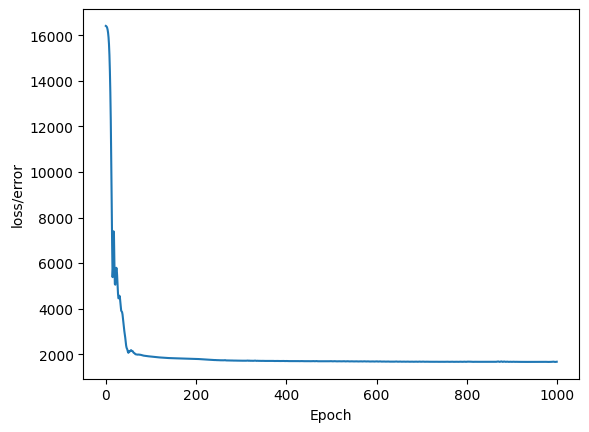

In [482]:
# Graph it out!
plt.plot(range(epochs), losses) # Plot the loss values over epochs
plt.ylabel("loss/error") # Label the y-axis
plt.xlabel('Epoch') # Label the x-axis

In [483]:
# Evaluate Model on Test Data Set (validate model on test set)
with torch.no_grad():  # Basically turn off back propogation (gradient calculation) to save memory and computation
  y_eval = model.forward(X_test) # X_test are features from our test set, y_eval will be predictions
  loss = criterion(y_eval.squeeze(), y_test) # Find the loss or error on the test set

print(f'Test Loss (MSE): {loss.item():.4f}')


Test Loss (MSE): 2071.0417


In [484]:
model.eval()  # Set model to evaluation mode
correct = 0
with torch.no_grad(): # Disable gradient calculation
  for i, data in enumerate(X_test): # Iterate over test data
    y_val = model.forward(data.unsqueeze(0)) # Add batch dimension: (24,) -> (1, 24)

    # Will tell us what RUL our network predicts
    print(f'{i+1}.) \t Predicted: {y_val.item():.2f} \t Actual: {y_test[i].item():.2f}')

# Calculate accuracy metrics for regression
with torch.no_grad():
  y_pred_all = model.forward(X_test)
  mae = torch.mean(torch.abs(y_pred_all.squeeze() - y_test))
  print(f'\nMean Absolute Error: {mae.item():.2f}')

1.) 	 Predicted: 174.66 	 Actual: 142.00
2.) 	 Predicted: 167.85 	 Actual: 141.00
3.) 	 Predicted: 160.60 	 Actual: 140.00
4.) 	 Predicted: 169.43 	 Actual: 139.00
5.) 	 Predicted: 184.80 	 Actual: 138.00
6.) 	 Predicted: 180.89 	 Actual: 137.00
7.) 	 Predicted: 166.15 	 Actual: 136.00
8.) 	 Predicted: 171.21 	 Actual: 135.00
9.) 	 Predicted: 166.34 	 Actual: 134.00
10.) 	 Predicted: 176.35 	 Actual: 133.00
11.) 	 Predicted: 179.05 	 Actual: 132.00
12.) 	 Predicted: 178.45 	 Actual: 131.00
13.) 	 Predicted: 177.48 	 Actual: 130.00
14.) 	 Predicted: 183.77 	 Actual: 129.00
15.) 	 Predicted: 166.64 	 Actual: 128.00
16.) 	 Predicted: 161.36 	 Actual: 127.00
17.) 	 Predicted: 181.01 	 Actual: 126.00
18.) 	 Predicted: 163.90 	 Actual: 125.00
19.) 	 Predicted: 184.12 	 Actual: 124.00
20.) 	 Predicted: 174.34 	 Actual: 123.00
21.) 	 Predicted: 169.70 	 Actual: 122.00
22.) 	 Predicted: 167.59 	 Actual: 121.00
23.) 	 Predicted: 179.88 	 Actual: 120.00
24.) 	 Predicted: 163.92 	 Actual: 119.00
2

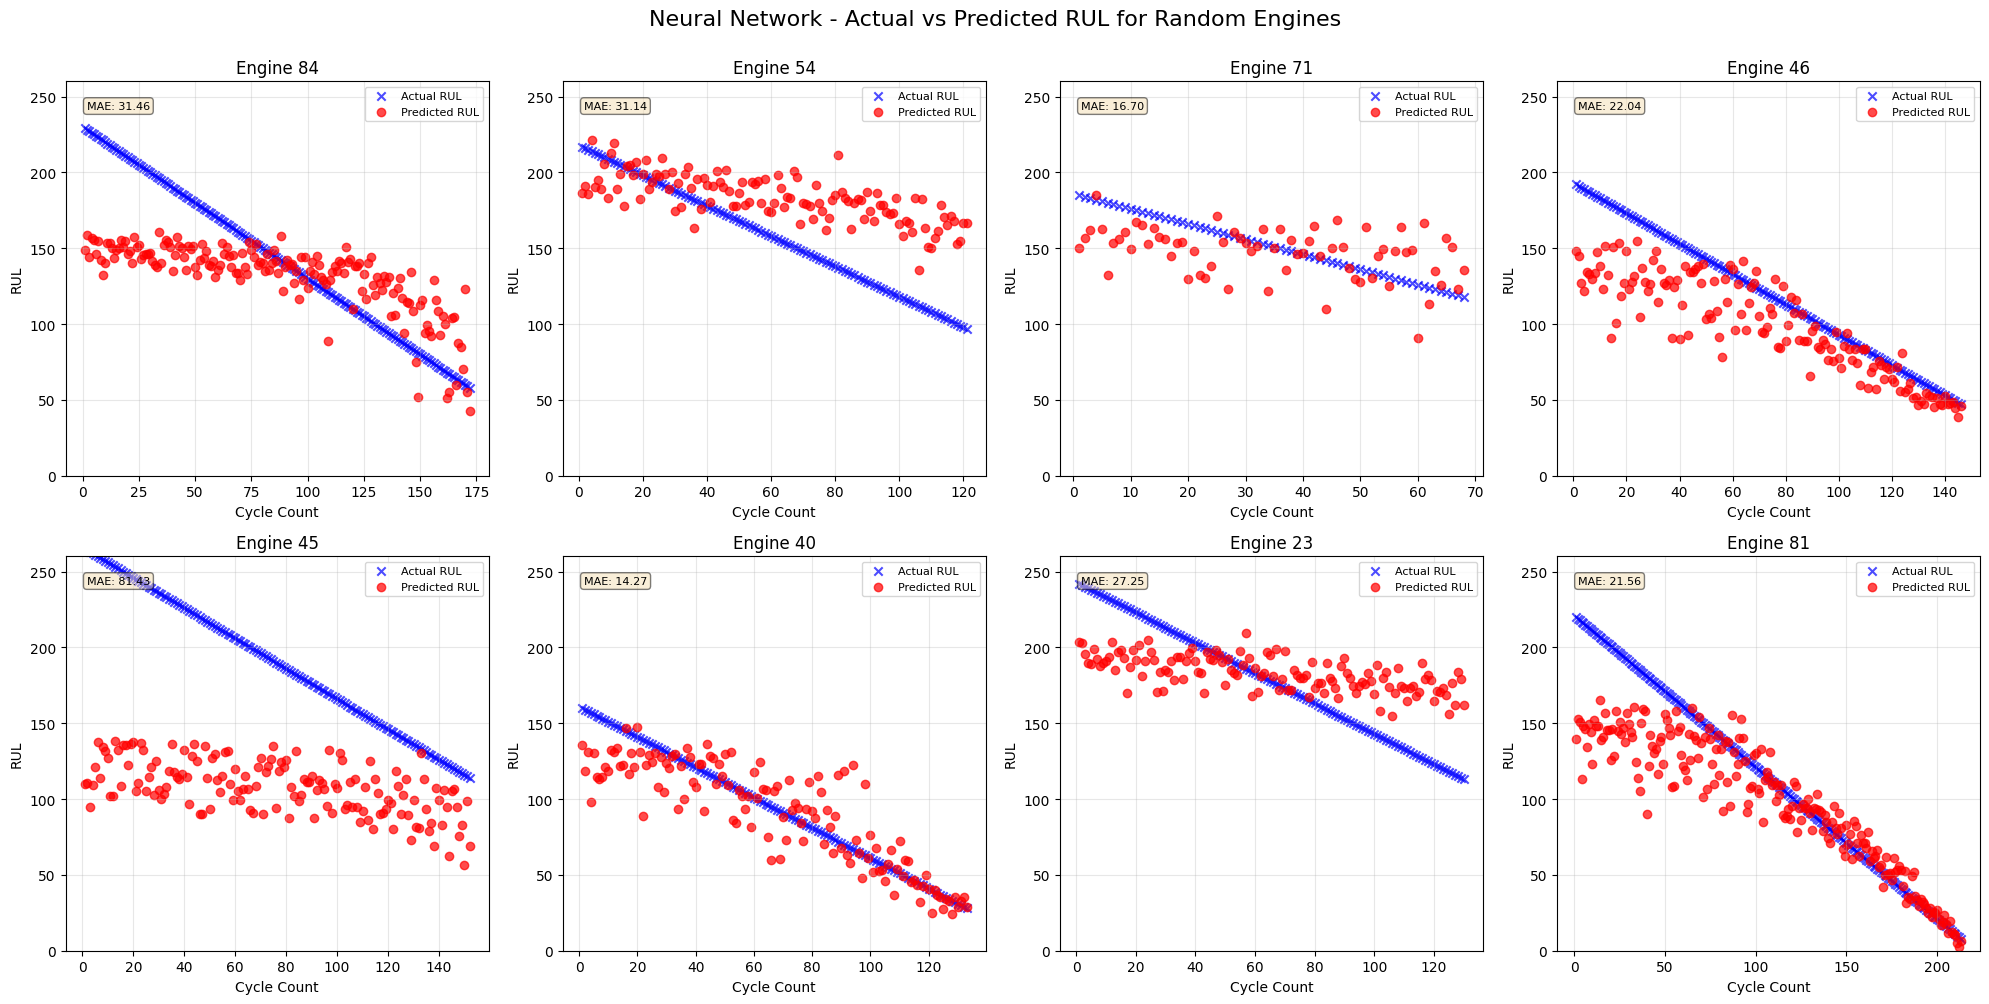

Summary Statistics for Selected Engines:
Engine 84: MAE = 31.46 cycles, Avg Error = 22.72%
Engine 54: MAE = 31.14 cycles, Avg Error = 23.69%
Engine 71: MAE = 16.70 cycles, Avg Error = 11.16%
Engine 46: MAE = 22.04 cycles, Avg Error = 16.74%
Engine 45: MAE = 81.43 cycles, Avg Error = 41.01%
Engine 40: MAE = 14.27 cycles, Avg Error = 15.45%
Engine 23: MAE = 27.25 cycles, Avg Error = 16.98%
Engine 81: MAE = 21.56 cycles, Avg Error = 16.87%


In [485]:
# Generate predictions for all test data
model.eval()
with torch.no_grad():
    y_predictions = model.forward(X_test).squeeze().numpy()

# Get unique engines and randomly select 8
unique_engines = Testing_df['engine'].unique()
np.random.seed(42)  # For reproducibility
selected_engines = np.random.choice(unique_engines, size=min(8, len(unique_engines)), replace=False)

# Create a figure with 8 subplots (2 rows x 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Neural Network - Actual vs Predicted RUL for Random Engines', fontsize=16, y=1.00)

# Flatten axes array for easier iteration
axes = axes.flatten()

# Plot each selected engine
for idx, engine_num in enumerate(selected_engines):
    # Filter for current engine
    engine_mask = Testing_df['engine'] == engine_num
    engine_df = Testing_df[engine_mask]
    
    # Extract cycle data and RUL values
    X_og = engine_df['cycle'].values
    Y_og = engine_df['RUL'].values
    
    # Get predictions for current engine
    y_pred_engine = y_predictions[engine_mask]
    
    # Plot on the corresponding subplot
    axes[idx].scatter(X_og, Y_og, label='Actual RUL', color='blue', alpha=0.7, marker='x')
    axes[idx].scatter(X_og, y_pred_engine, label='Predicted RUL', color='red', alpha=0.7)
    axes[idx].set_title(f'Engine {engine_num}')
    axes[idx].set_xlabel('Cycle Count')
    axes[idx].set_ylabel('RUL')
    axes[idx].set_ylim(0, 260)  # Set y-axis limits from 0 to 260
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)
    
    # Calculate and display MAE for this engine
    mae_engine = np.mean(np.abs(Y_og - y_pred_engine))
    axes[idx].text(0.05, 0.95, f'MAE: {mae_engine:.2f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                   fontsize=8)

plt.tight_layout()
plt.show()

# Print summary statistics for all selected engines
print("Summary Statistics for Selected Engines:")
print("="*60)
for engine_num in selected_engines:
    engine_mask = Testing_df['engine'] == engine_num
    Y_og = Testing_df[engine_mask]['RUL'].values
    y_pred_engine = y_predictions[engine_mask]
    
    mae = np.mean(np.abs(Y_og - y_pred_engine))
    errors = (Y_og - y_pred_engine) / Y_og * 100
    avg_error = np.mean(np.abs(errors))
    
    print(f"Engine {engine_num}: MAE = {mae:.2f} cycles, Avg Error = {avg_error:.2f}%")


8 Engines with lowest final RUL:
  Engine 34: Final RUL = 7.0
  Engine 31: Final RUL = 8.0
  Engine 68: Final RUL = 8.0
  Engine 81: Final RUL = 8.0
  Engine 82: Final RUL = 9.0
  Engine 42: Final RUL = 10.0
  Engine 76: Final RUL = 10.0
  Engine 35: Final RUL = 11.0


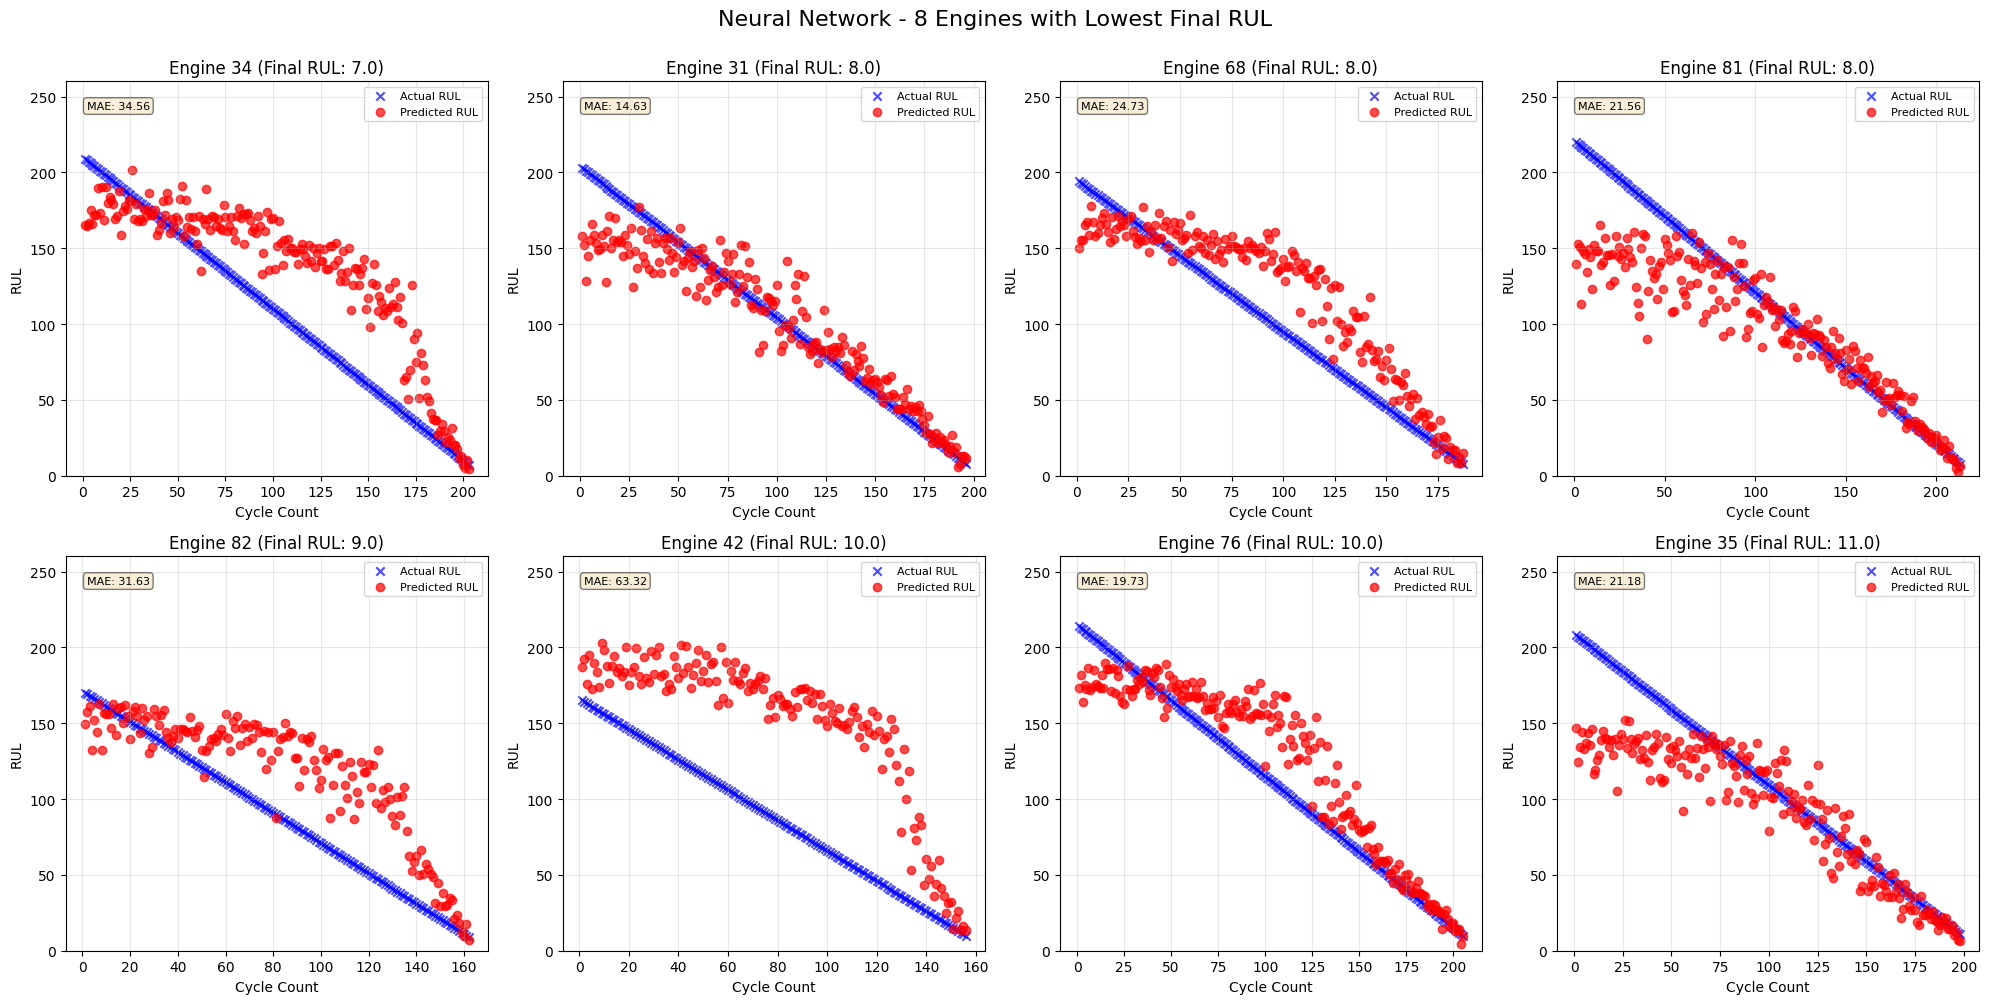


Summary Statistics for 8 Engines with Lowest Final RUL:
Engine 34 (Final RUL: 7.0): MAE = 34.56 cycles, Avg Error = 48.50%
Engine 31 (Final RUL: 8.0): MAE = 14.63 cycles, Avg Error = 15.60%
Engine 68 (Final RUL: 8.0): MAE = 24.73 cycles, Avg Error = 33.26%
Engine 81 (Final RUL: 8.0): MAE = 21.56 cycles, Avg Error = 16.87%
Engine 82 (Final RUL: 9.0): MAE = 31.63 cycles, Avg Error = 53.25%
Engine 42 (Final RUL: 10.0): MAE = 63.32 cycles, Avg Error = 95.75%
Engine 76 (Final RUL: 10.0): MAE = 19.73 cycles, Avg Error = 19.81%
Engine 35 (Final RUL: 11.0): MAE = 21.18 cycles, Avg Error = 18.06%


In [486]:
# Generate predictions for engines with the 8 lowest final RUL values
model.eval()
with torch.no_grad():
    y_predictions = model.forward(X_test).squeeze().numpy()

# Get final RUL for each engine and sort to find the 8 lowest
engine_final_rul = []
for engine_num in Testing_df['engine'].unique():
    engine_data = Testing_df[Testing_df['engine'] == engine_num]
    last_rul = engine_data['RUL'].iloc[-1]  # Get the last RUL value
    engine_final_rul.append((engine_num, last_rul))

# Sort by final RUL (ascending) and select the 8 engines with lowest final RUL
engine_final_rul.sort(key=lambda x: x[1])
selected_engines = [engine_num for engine_num, _ in engine_final_rul[:8]]

print(f"8 Engines with lowest final RUL:")
for engine_num, final_rul in engine_final_rul[:8]:
    print(f"  Engine {engine_num}: Final RUL = {final_rul:.1f}")

# Create a figure with 8 subplots (2 rows x 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Neural Network - 8 Engines with Lowest Final RUL', fontsize=16, y=1.00)

# Flatten axes array for easier iteration
axes = axes.flatten()

# Plot each selected engine
for idx, engine_num in enumerate(selected_engines):
    # Filter for current engine
    engine_mask = Testing_df['engine'] == engine_num
    engine_df = Testing_df[engine_mask]
    
    # Extract cycle data and RUL values
    X_og = engine_df['cycle'].values
    Y_og = engine_df['RUL'].values
    
    # Get predictions for current engine
    y_pred_engine = y_predictions[engine_mask]
    
    # Get final RUL value
    final_rul = Y_og[-1]
    
    # Plot on the corresponding subplot
    axes[idx].scatter(X_og, Y_og, label='Actual RUL', color='blue', alpha=0.7, marker='x')
    axes[idx].scatter(X_og, y_pred_engine, label='Predicted RUL', color='red', alpha=0.7)
    axes[idx].set_title(f'Engine {engine_num} (Final RUL: {final_rul:.1f})')
    axes[idx].set_xlabel('Cycle Count')
    axes[idx].set_ylabel('RUL')
    axes[idx].set_ylim(0, 260)  # Set y-axis limits from 0 to 260
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)
    
    # Calculate and display MAE for this engine
    mae_engine = np.mean(np.abs(Y_og - y_pred_engine))
    axes[idx].text(0.05, 0.95, f'MAE: {mae_engine:.2f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                   fontsize=8)

plt.tight_layout()
plt.show()

# Print summary statistics for all selected engines
print("\nSummary Statistics for 8 Engines with Lowest Final RUL:")
print("="*60)
for engine_num in selected_engines:
    engine_mask = Testing_df['engine'] == engine_num
    engine_df = Testing_df[engine_mask]
    Y_og = engine_df['RUL'].values
    y_pred_engine = y_predictions[engine_mask]
    final_rul = Y_og[-1]
    
    mae = np.mean(np.abs(Y_og - y_pred_engine))
    errors = (Y_og - y_pred_engine) / Y_og * 100
    avg_error = np.mean(np.abs(errors))
    
    print(f"Engine {engine_num} (Final RUL: {final_rul:.1f}): MAE = {mae:.2f} cycles, Avg Error = {avg_error:.2f}%")
